# 7. Model comparison

Every preceding notebook writes its scores to `results/metrics.csv` via
`src.results.record_result`. This notebook reads them back and assembles the
comparison tables.

Run notebooks 01 through 06 first — this one only reports what they recorded.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd

from src.results import load_results
from src.plotting import metrics_table

results = load_results()
results

,model,split,mse,r_squared,accuracy,precision,f_score
0,Elastic net,test,1.984829,0.908297,NaN,NaN,NaN
1,Elastic net,train,1.875560,0.917734,NaN,NaN,NaN
2,Kernel SVM (sigma=0.01),test,NaN,NaN,0.863248,0.000000,0.000000
3,Kernel SVM (sigma=0.01),train,NaN,NaN,0.838828,0.000000,0.000000
4,Kernel SVM (sigma=0.1),test,NaN,NaN,0.923077,0.818182,0.666667
5,Kernel SVM (sigma=0.1),train,NaN,NaN,0.930403,0.878788,0.753247
6,Kernel SVM (sigma=1),test,NaN,NaN,0.923077,0.733333,0.709677
7,Kernel SVM (sigma=1),train,NaN,NaN,0.985348,0.976190,0.953488
8,Kernel SVM (sigma=2),test,NaN,NaN,0.905983,0.647059,0.666667
9,Kernel SVM (sigma=2),train,NaN,NaN,0.992674,1.000000,0.976744


## Regression models

In [2]:
regression = results.dropna(subset=["mse"]).copy()
regression_table = regression.pivot(index="model", columns="split",
                                    values=["mse", "r_squared"])
regression_table.round(4)

mse         r_squared        
split            test   train      test   train
model                                          
Elastic net    1.9848  1.8756    0.9083  0.9177
Lasso          1.9848  1.8759    0.9083  0.9177
Least squares  1.9844  1.8756    0.9083  0.9177
kNN            2.9857  2.3574    0.8621  0.8966

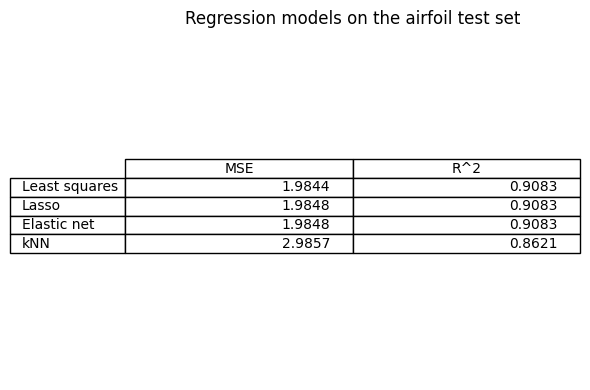

In [3]:
test_regression = regression[regression["split"] == "test"].sort_values("r_squared", ascending=False)

metrics_table(test_regression[["mse", "r_squared"]].to_numpy(),
              columns=("MSE", "R^2"),
              row_labels=list(test_regression["model"]),
              title="Regression models on the airfoil test set")

## Classification models

In [4]:
classification = results.dropna(subset=["accuracy"]).copy()
classification_table = classification.pivot(index="model", columns="split",
                                            values=["accuracy", "precision", "f_score"])
classification_table.round(4)

accuracy         precision         f_score        
split                        test   train      test   train    test   train
model                                                                      
Kernel SVM (sigma=0.01)    0.8632  0.8388    0.0000  0.0000  0.0000  0.0000
Kernel SVM (sigma=0.1)     0.9231  0.9304    0.8182  0.8788  0.6667  0.7532
Kernel SVM (sigma=1)       0.9231  0.9853    0.7333  0.9762  0.7097  0.9535
Kernel SVM (sigma=2)       0.9060  0.9927    0.6471  1.0000  0.6667  0.9767
Linear SVM                 0.9402  0.9048    0.7647  0.6800  0.7879  0.7234
Random forest              0.8889  0.9707    0.6000  0.9737  0.5806  0.9024
Random forest (weighted)   0.9060  0.9853    0.6190  0.9167  0.7027  0.9565

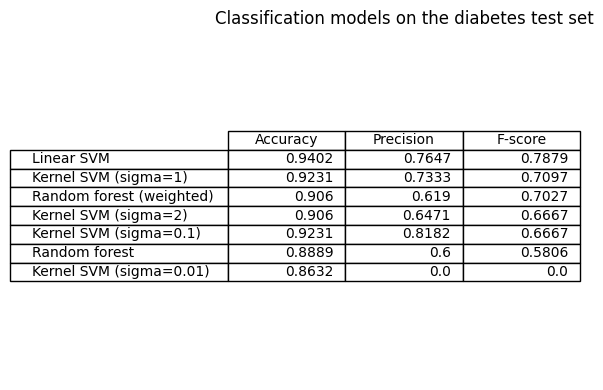

In [5]:
test_classification = classification[classification["split"] == "test"].sort_values("f_score", ascending=False)

metrics_table(test_classification[["accuracy", "precision", "f_score"]].to_numpy(),
              columns=("Accuracy", "Precision", "F-score"),
              row_labels=list(test_classification["model"]),
              title="Classification models on the diabetes test set")

## Notes on reading this table

Accuracy is a weak guide on the diabetes data, where roughly 84% of patients are
non-diabetic and a constant "not diabetic" prediction would score about that
much. F-score is the more informative column, since it responds to whether the
model identifies the minority class at all.

For the regression models the R^2 values sit close together, so small differences
should not be over-read — particularly as the shrinkage hyperparameters were
tuned on cross-validated folds drawn from the same training data.